In [5]:
import sys
sys.path.append('./')

In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from component.ibm_simulator.sim_machine5qubits import FakeVigoV2
from flow.schedule.circuit_adjustment import Circuit_adjustment

In [7]:
# Construct quantum circuit
circ = QuantumCircuit(3, 3)
circ.h(0)
circ.cx(0, 1)
circ.cx(1, 2)
circ.measure([0, 1, 2], [0, 1, 2])
# Execute and get counts
circuittranspiled = transpile(circ, AerSimulator())
circuittranspiled.draw('mpl')
result = AerSimulator().run(circuittranspiled).result()
print(result)
counts = result.get_counts(0)
# plot_histogram(counts, title='Ideal counts for 3-qubit GHZ state')
sim_vigo = AerSimulator.from_backend(FakeVigoV2())

Result(backend_name='aer_simulator', backend_version='0.17.2', job_id='f363bbf8-83cc-43fc-ac85-402a268de0f7', success=True, results=[ExperimentResult(shots=1024, success=True, meas_level=2, data=ExperimentResultData(counts={'0x7': 490, '0x0': 534}), header={'creg_sizes': [['c', 3]], 'global_phase': 0.0, 'memory_slots': 3, 'n_qubits': 3, 'name': 'circuit-464', 'qreg_sizes': [['q', 3]], 'metadata': {}}, status=DONE, seed_simulator=1130515999, metadata={'time_taken': 0.00068212, 'num_bind_params': 1, 'parallel_state_update': 12, 'parallel_shots': 1, 'required_memory_mb': 0, 'input_qubit_map': [[2, 2], [1, 1], [0, 0]], 'method': 'stabilizer', 'device': 'CPU', 'num_qubits': 3, 'sample_measure_time': 0.000395362, 'active_input_qubits': [0, 1, 2], 'num_clbits': 3, 'remapped_qubits': False, 'runtime_parameter_bind': False, 'max_memory_mb': 15333, 'noise': 'ideal', 'measure_sampling': True, 'batched_shots_optimization': False, 'fusion': {'enabled': False}}, time_taken=0.00068212)], date=2026-02

Result(backend_name='aer_simulator_from(fake_vigo)', backend_version='1.3.6', job_id='afc338c2-6fc6-444c-96ec-943f6bd12c3e', success=True, results=[ExperimentResult(shots=1024, success=True, meas_level=2, data=ExperimentResultData(counts={'0x4': 7, '0x5': 15, '0x6': 39, '0x2': 5, '0x0': 467, '0x1': 38, '0x3': 5, '0x7': 448}), header={'creg_sizes': [['c', 3]], 'global_phase': 0.7853981633974483, 'memory_slots': 3, 'n_qubits': 5, 'name': 'circuit-464', 'qreg_sizes': [['q', 5]], 'metadata': {}}, status=DONE, seed_simulator=3994699530, metadata={'time_taken': 0.00890078, 'num_bind_params': 1, 'parallel_state_update': 12, 'parallel_shots': 1, 'required_memory_mb': 1, 'input_qubit_map': [[2, 2], [1, 1], [0, 0]], 'method': 'density_matrix', 'device': 'CPU', 'num_qubits': 3, 'sample_measure_time': 0.006847488, 'active_input_qubits': [0, 1, 2], 'num_clbits': 3, 'remapped_qubits': False, 'runtime_parameter_bind': False, 'max_memory_mb': 15333, 'noise': 'superop', 'measure_sampling': True, 'batch

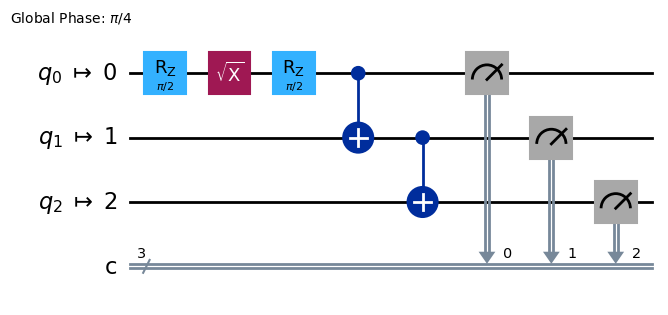

In [8]:
# Transpile the circuit for the noisy basis gates
tcirc = transpile(circ, sim_vigo, optimization_level=3, initial_layout=[0, 1, 2])


# Execute noisy simulation and get counts
result_noise = sim_vigo.run(tcirc)
result_noise = result_noise.result()
print(result_noise)
counts_noise = result_noise.get_counts(0)
# plot_histogram(counts_noise,
#                title="Counts for 3-qubit GHZ state with device noise model")
# plot_circuit_layout(tcirc, FakeVigoV2())
tcirc.draw('mpl')

Mapping cuối cùng:
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
Thứ tự vật lý cho toàn bộ register: [0, 1, 2, 3, 4]


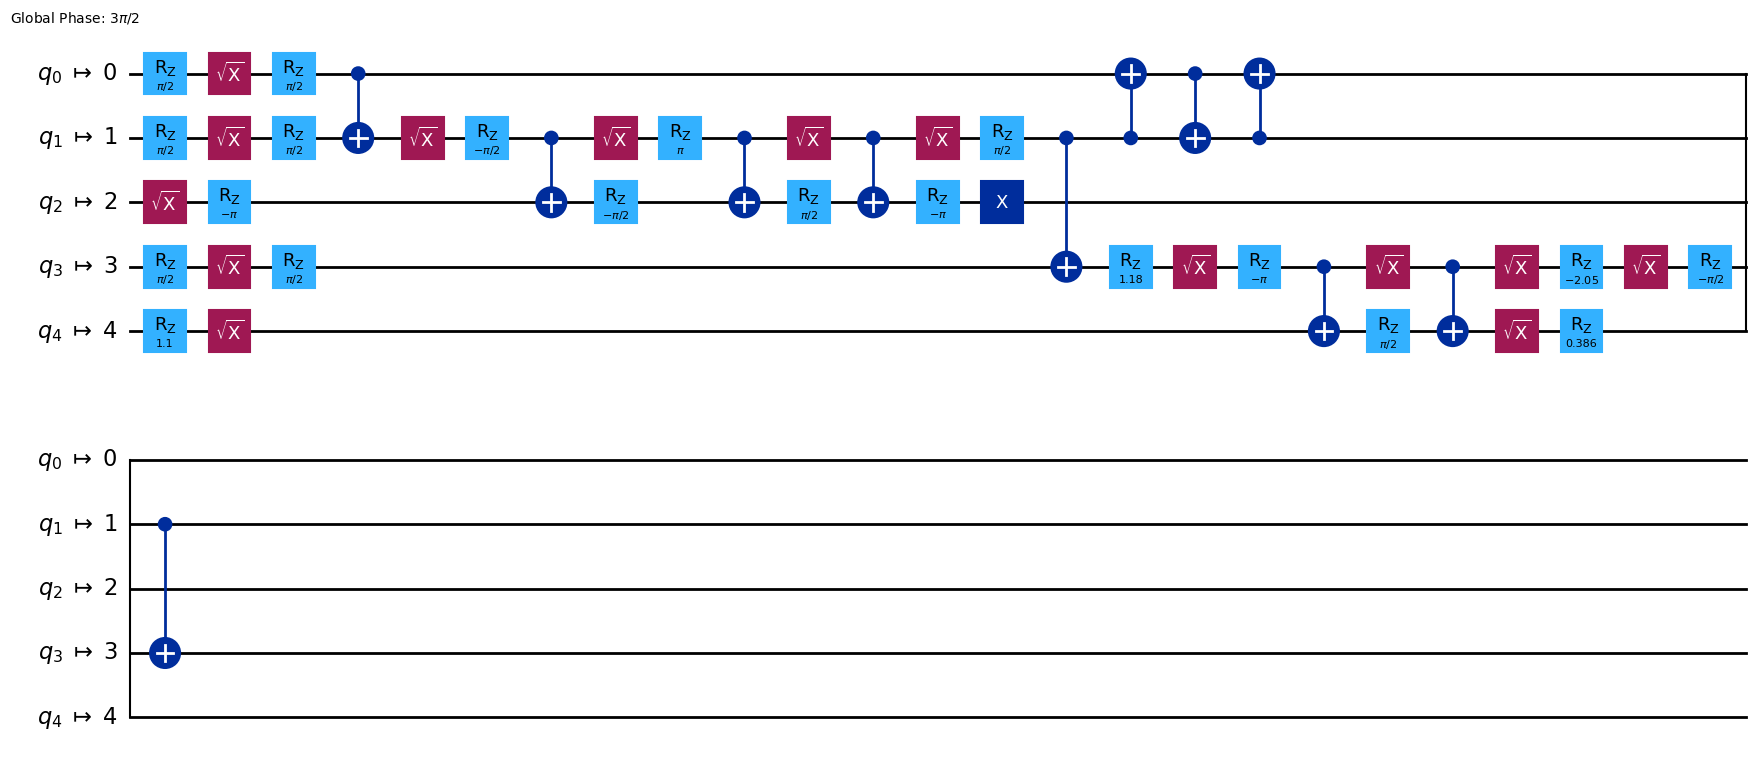

In [13]:
from qiskit import QuantumCircuit, transpile

backend = FakeVigoV2()
qc = QuantumCircuit(5)
# Giả lập một mạch có tương tác phức tạp
qc.h(range(5))
qc.cx(0, 1)
qc.cx(2, 3)
qc.cx(3, 4)
qc.cx(0, 4)

# MỤC TIÊU: Logic 0->0, 1->1, 2->2. Còn 3 và 4 tùy ý.

# Cách thực hiện "mẹo": 
# Ta tạo ra các phương án layout đầy đủ khả thi và để transpile chọn cái tốt nhất.
# Với máy 5 qubit, sau khi chốt 0,1,2 thì chỉ còn 2 phương án cho q3,q4 là (3,4) hoặc (4,3).

layouts = [
    [0, 1, 2, 4, 3],
    [0, 1, 2, 3, 4]  # Phương án B
]

# Thử transpile với cả 2 phương án và chọn cái có độ sâu (depth) thấp nhất hoặc ít lỗi nhất
best_circuit = None
min_depth = float('inf')

for layout in layouts:
    # transpile với layout cụ thể
    t_qc = transpile(qc, backend, initial_layout=layout, optimization_level=3)
    if t_qc.depth() < min_depth:
        min_depth = t_qc.depth()
        best_circuit = t_qc

print("Mapping cuối cùng:")
# Use the get_qubit_mapping function defined earlier
mapping, physical_order = Circuit_adjustment.get_qubit_mapping(best_circuit)
print(mapping)
print("Thứ tự vật lý cho toàn bộ register:", physical_order)

best_circuit.draw('mpl')